In [10]:
import pandas as pd
df = pd.read_csv("city_temperature.csv", low_memory=False)

,Region,Country,State,City,Month,Day,Year,AvgTemperature
0,Africa,Algeria,NaN,Algiers,1,1,1995,64.2
1,Africa,Algeria,NaN,Algiers,1,2,1995,49.4
2,Africa,Algeria,NaN,Algiers,1,3,1995,48.8
3,Africa,Algeria,NaN,Algiers,1,4,1995,46.4
4,Africa,Algeria,NaN,Algiers,1,5,1995,47.9
5,Africa,Algeria,NaN,Algiers,1,6,1995,48.7
6,Africa,Algeria,NaN,Algiers,1,7,1995,48.9
7,Africa,Algeria,NaN,Algiers,1,8,1995,49.1
8,Africa,Algeria,NaN,Algiers,1,9,1995,49.0
9,Africa,Algeria,NaN,Algiers,1,10,1995,51.9


In [11]:
df.head(n=10)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2906327 entries, 0 to 2906326
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Region          object 
 1   Country         object 
 2   State           object 
 3   City            object 
 4   Month           int64  
 5   Day             int64  
 6   Year            int64  
 7   AvgTemperature  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 177.4+ MB


In [29]:
city_df = df[df['City'] == 'Algiers'].copy()
city_df.isnull().sum()
city_df = city_df.dropna(axis = 1).drop(columns = ['Region', 'Country', 'City'])
city_df

,Month,Day,Year,AvgTemperature
0,1,1,1995,64.2
1,1,2,1995,49.4
2,1,3,1995,48.8
3,1,4,1995,46.4
4,1,5,1995,47.9
...,...,...,...,...
9261,5,9,2020,70.8
9262,5,10,2020,67.1
9263,5,11,2020,68.9
9264,5,12,2020,69.8


In [30]:
import datetime as dt
city_df['Date'] = pd.to_datetime(city_df[['Year', 'Month', 'Day']], errors='coerce')
city_df['Date Ordinal'] = city_df['Date'].map(dt.datetime.toordinal)
city_df

,Month,Day,Year,AvgTemperature,Date,Date Ordinal
0,1,1,1995,64.2,1995-01-01,728294
1,1,2,1995,49.4,1995-01-02,728295
2,1,3,1995,48.8,1995-01-03,728296
3,1,4,1995,46.4,1995-01-04,728297
4,1,5,1995,47.9,1995-01-05,728298
...,...,...,...,...,...,...
9261,5,9,2020,70.8,2020-05-09,737554
9262,5,10,2020,67.1,2020-05-10,737555
9263,5,11,2020,68.9,2020-05-11,737556
9264,5,12,2020,69.8,2020-05-12,737557


In [31]:
train_data = city_df[city_df['Year'] <= 2015]
test_data = city_df[city_df['Year'] > 2015]

In [ ]:
import datetime as dt

# 1. Prepare train/test splits safely
train_data = city_df[city_df["Year"] <= 2015].copy()
test_data = city_df[city_df["Year"] > 2015].copy()


# 2. Linear Regression Training Function
def train_model(X, y):
  x_mean = X.mean()
  y_mean = y.mean()

  numerator = ((X - x_mean) * (y - y_mean)).sum()
  denominator = ((X - x_mean) ** 2).sum()

  b1 = numerator / denominator
  b0 = y_mean - (b1 * x_mean)

  return b0, b1


# 3. Predict Function
def predict_temperature(X, b0, b1):
  return b0 + (b1 * X)


# 4. Train
X_train = train_data["Date Ordinal"]
y_train = train_data["AvgTemperature"]

b0, b1 = train_model(X_train, y_train)

print(f"Intercept (b0): {b0}")
print(f"Slope (b1): {b1}")

# 5. Test & Evaluate
X_test = test_data["Date Ordinal"]
y_test = test_data["AvgTemperature"]

# Predict
test_data["Predicted_Temperature"] = predict_temperature(X_test, b0, b1)
y_pred = test_data["Predicted_Temperature"]

Intercept (b0): -86.45888239177813
Slope (b1): 0.00020544326852371748
MSE: 367.21774100205494


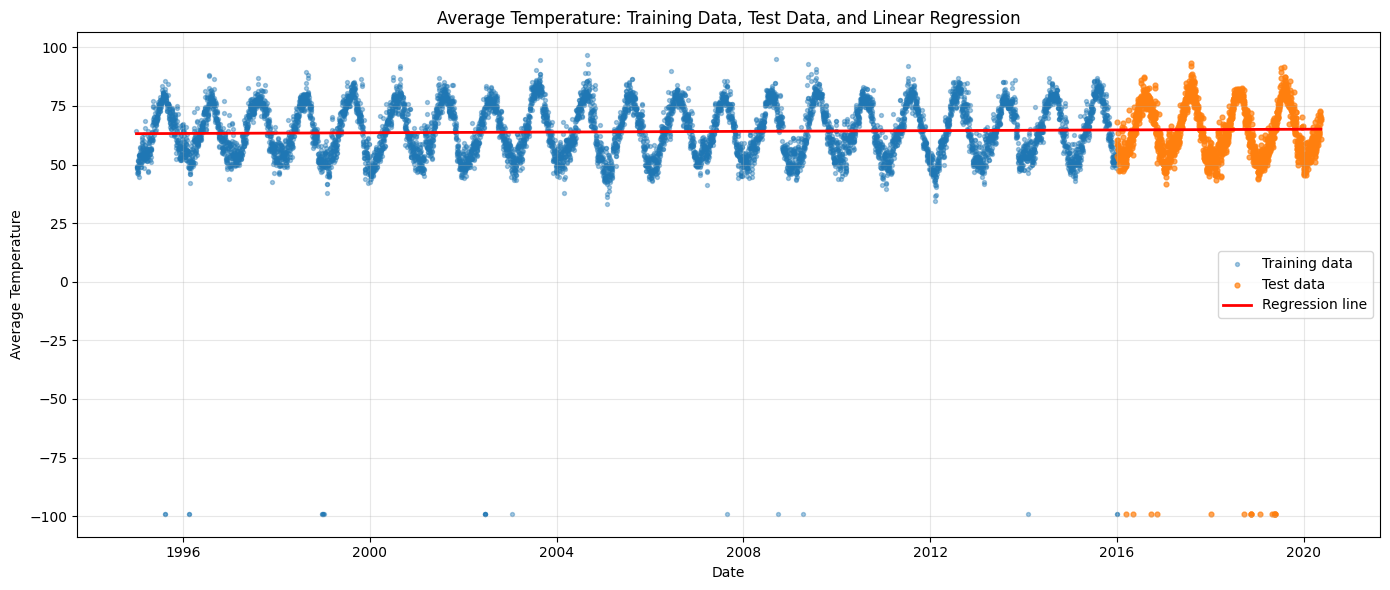

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.scatter(
    train_data["Date"],
    train_data["AvgTemperature"],
    s=8,
    alpha=0.4,
    label="Training data"
)

plt.scatter(
    test_data["Date"],
    test_data["AvgTemperature"],
    s=12,
    alpha=0.7,
    label="Test data"
)

all_dates = city_df["Date"]
regression_values = predict_temperature(city_df["Date Ordinal"], b0, b1)

plt.plot(
    all_dates,
    regression_values,
    color="red",
    linewidth=2,
    label="Regression line"
)

plt.xlabel("Date")
plt.ylabel("Average Temperature")
plt.title("Average Temperature: Training Data, Test Data, and Linear Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
mse = ((y_test - y_pred) ** 2).mean()
print(f"MSE: {mse}")

MSE: 367.21774100205494


**2. Model Suitability (Underfitting)**
The plot clearly illustrates why **simple linear regression is inappropriate for seasonal weather data**:

* **Cyclical Pattern:** Temperatures naturally follow a sinusoidal/periodic wave across the months (peaking in summer, dropping in winter).
* **Linear Constraint:** A simple linear model ($y = b_0 + b_1 X$) can only draw a single straight line. It captures the flat long-term trend line, but misses every seasonal peak and valley, leading to a high MSE (~367).
* **Better Alternatives:** To model this accurately, algorithms that capture seasonality work best (e.g., Polynomial Regression, Sine/Cosine feature engineering, SARIMA, or Random Forest Regressors).